## PRODUCT PERFORMANCE ANALYSIS

In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_dict=pd.read_csv('data/data_dictionary.csv')
sessions = pd.read_csv("data/website_sessions.csv")
pageviews = pd.read_csv("data/website_pageviews.csv")
orders = pd.read_csv("data/orders.csv")
order_items = pd.read_csv("data/order_items.csv")
refunds = pd.read_csv("data/order_item_refunds.csv")
products = pd.read_csv("data/products.csv")

In [86]:
data_dict # this table gives the contents in each datasets


,Table,Field,Description
0,orders,order_id,Unique identifier for each order (PK)
1,orders,created_at,Timestamp when the order was placed
2,orders,website_session_id,Unique identifier for the website session (FK)
3,orders,user_id,Unique identifier for the user (FK)
4,orders,primary_product_id,Unique identifier for the primary product in t...
5,orders,items_purchased,Number of items in the order
6,orders,price_usd,Total price for the items in the order
7,orders,cogs_usd,Cost of goods sold for the items in the order
8,order_items,order_item_id,Unique identifier for each order item (PK)
9,order_items,created_at,Timestamp when the order was placed


In [65]:
products 

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [88]:
orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


In [89]:
order_items

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49
...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49


## PRODUCT SALES VOLUME 

In [90]:
products

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [91]:
product_sales = order_items.groupby('product_id')['order_item_id'].count().reset_index() 
product_sales.columns = ['product_id', 'Units_sold'] 

In [92]:
product_sales # total units sold per product


,product_id,Units_sold
0,1,24226
1,2,5796
2,3,4985
3,4,5018


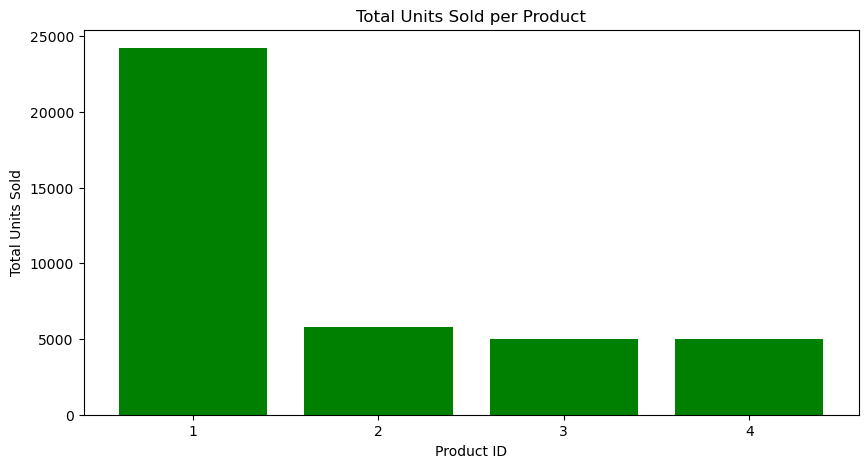

In [93]:
plt.figure(figsize=(10, 5))
plt.bar(product_sales["product_id"].astype(str), product_sales["Units_sold"],color='green')
plt.xlabel("Product ID")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold per Product")
plt.show()


**Insights:**
* Product 1 has the highest sales (24,000 units).

* Products 2, 3, and 4 have much lower and similar sales (5,000 – 6,000 units).

* Big sales gap between Product 1 and the rest.

* Products 3 and 4 have nearly identical performance.

* Overall: Product 1 is the top-performing product by a large margin.

In [94]:
total_orders=product_sales["Units_sold"].sum()# total products ordered
total_orders

np.int64(40025)

In [95]:
orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


In [96]:
sales_revenue=orders["price_usd"].sum()# overall sales revenue
sales_revenue

np.float64(1938509.7500000002)

## UNIQUE PRICE PER PRODUCT

In [97]:
order_items

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49
...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49


In [98]:
order_items.groupby("product_id")["price_usd"].unique()

product_id
1    [49.99]
2    [59.99]
3    [45.99]
4    [29.99]
Name: price_usd, dtype: object

## AVERAGE ORDER VALUE

In [99]:
order_items.groupby("product_id")["price_usd"].unique()

product_id
1    [49.99]
2    [59.99]
3    [45.99]
4    [29.99]
Name: price_usd, dtype: object

In [100]:
average_order_value = orders["price_usd"].mean()
average_order_value

np.float64(59.99163649305234)

## PRODUCT COMBINATIONS 

In [101]:
product_pairs = order_items.merge(order_items, on="order_id")

In [102]:
product_pairs = product_pairs[
    product_pairs["product_id_x"] != product_pairs["product_id_y"]
]


In [103]:
product_pairs["pair"] = product_pairs.apply(
    lambda row: "-".join(sorted([str(row["product_id_x"]), str(row["product_id_y"])])),
    axis=1
)


In [104]:
pair_counts = (
    product_pairs.groupby("pair")
    .size()
    .reset_index(name="times_bought_together")
    .sort_values("times_bought_together", ascending=False)
)
pair_counts

,pair,times_bought_together
2,1-4,6284
1,1-3,4072
0,1-2,1888
4,2-4,1360
5,3-4,1324
3,2-3,496


In [105]:
refunds

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99
...,...,...,...,...,...
1726,1727,2015-03-30 09:37:23,39950,32255,59.99
1727,1728,2015-03-30 21:33:51,39671,32049,49.99
1728,1729,2015-03-31 19:59:48,39729,32090,49.99
1729,1730,2015-04-01 03:54:48,39717,32079,59.99


In [106]:
refunds.columns

Index(['order_item_refund_id', 'created_at', 'order_item_id', 'order_id',
       'refund_amount_usd'],
      dtype='object')

In [107]:
total_refund=refunds["order_item_id"].nunique()
total_refund

1731

In [108]:
actual_orders=total_orders-total_refund
actual_orders

np.int64(38294)

In [109]:
refund_amt=refunds["refund_amount_usd"].sum()
refund_amt

np.float64(85338.69)

## AVERAGE REFUND

In [110]:
refund_mean=refunds["refund_amount_usd"].mean()
refund_mean

np.float64(49.3002253032929)

In [111]:
refunds_per_order = (refunds.groupby("order_id")["refund_amount_usd"].sum().reset_index(name="total_refunded_usd"))
refunds_per_order

,order_id,total_refunded_usd
0,57,49.99
1,71,49.99
2,74,49.99
3,116,49.99
4,118,49.99
...,...,...
1718,32152,49.99
1719,32156,45.99
1720,32191,49.99
1721,32252,45.99


In [112]:
cogs_per_order = (order_items.groupby("order_item_id")["cogs_usd"].sum().reset_index(name="total_cogs_usd"))
cogs_per_order

,order_item_id,total_cogs_usd
0,1,19.49
1,2,19.49
2,3,19.49
3,4,19.49
4,5,19.49
...,...,...
40020,40021,9.49
40021,40022,22.49
40022,40023,9.49
40023,40024,9.49


## REFUND MERGED WITH ORDER ITEMS

In [113]:
refunds_items = pd.merge( refunds, order_items, on="order_item_id")
refunds_items


,order_item_refund_id,created_at_x,order_item_id,order_id_x,refund_amount_usd,created_at_y,order_id_y,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-04-06 11:32:43,57,57,49.99,2012-03-31 02:32:43,57,1,1,49.99,19.49
1,2,2012-04-13 01:09:43,74,74,49.99,2012-04-03 19:09:43,74,1,1,49.99,19.49
2,3,2012-04-15 07:03:48,71,71,49.99,2012-04-03 15:03:48,71,1,1,49.99,19.49
3,4,2012-04-17 20:00:37,118,118,49.99,2012-04-15 09:00:37,118,1,1,49.99,19.49
4,5,2012-04-22 20:53:49,116,116,49.99,2012-04-13 14:53:49,116,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...,...,...,...
1726,1727,2015-03-30 09:37:23,39950,32255,59.99,2015-03-18 10:37:23,32255,2,1,59.99,22.49
1727,1728,2015-03-30 21:33:51,39671,32049,49.99,2015-03-15 15:33:51,32049,1,1,49.99,19.49
1728,1729,2015-03-31 19:59:48,39729,32090,49.99,2015-03-16 10:59:48,32090,1,1,49.99,19.49
1729,1730,2015-04-01 03:54:48,39717,32079,59.99,2015-03-16 08:54:48,32079,2,0,59.99,22.49


In [114]:
refund_counts = refunds_items.groupby('product_id')['order_item_id'].count().reset_index()
refund_counts.columns = ['product_id', 'total_refunds']

## TOTAL REFUNDS PER PRODUCT

In [115]:
refund_counts

,product_id,total_refunds
0,1,1237
1,2,129
2,3,301
3,4,64


In [116]:
prod_refund = pd.merge( refund_counts, product_sales, on="product_id")
prod_refund

,product_id,total_refunds,Units_sold
0,1,1237,24226
1,2,129,5796
2,3,301,4985
3,4,64,5018


## REFUND RATE

In [117]:
prod_refund["refund_rate_%"]=(prod_refund['total_refunds']/prod_refund['Units_sold'])*100

In [118]:
prod_refund

,product_id,total_refunds,Units_sold,refund_rate_%
0,1,1237,24226,5.106084
1,2,129,5796,2.225673
2,3,301,4985,6.038114
3,4,64,5018,1.275409


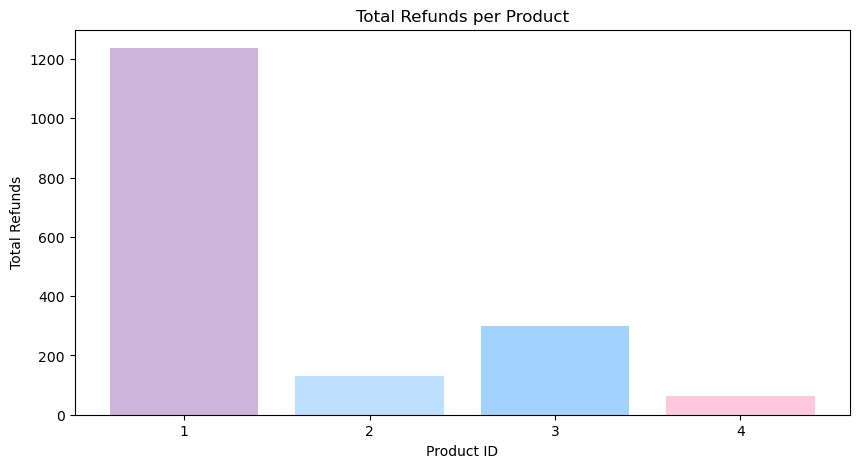

In [119]:
plt.figure(figsize=(10,5))
plt.bar(refund_counts['product_id'].astype(str), refund_counts['total_refunds'],color=['#cdb4db', '#bde0fe', '#a2d2ff', '#ffc8dd'])
plt.xlabel("Product ID")
plt.ylabel("Total Refunds")
plt.title("Total Refunds per Product")
plt.show()

**Insights:**

* Product 1 stands out with the highest number of refunds, far exceeding the others.

* Product 3 has the second-highest refunds, but much lower than Product 1.

* Product 2 has relatively low refunds.

* Product 4 performs best in terms of refunds, with the smallest number recorded

In [120]:
sales_per_product = order_items.groupby('product_id')['price_usd'].sum().reset_index()
sales_per_product.columns = ['product_id', 'sales_revenue']
sales_per_product 

,product_id,sales_revenue
0,1,1211057.74
1,2,347702.04
2,3,229260.15
3,4,150489.82


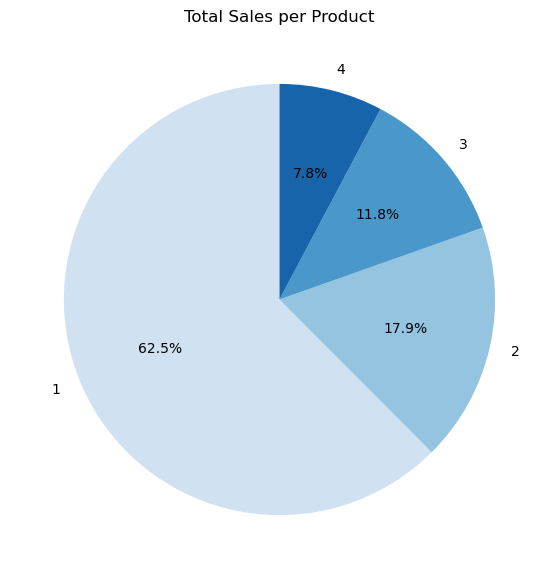

In [164]:
colors = sns.color_palette("Blues", len(sales_per_product))
plt.figure(figsize=(7,7))
plt.pie(sales_per_product['sales_revenue'],labels=sales_per_product['product_id'].astype(str),autopct='%1.1f%%',startangle=90,colors=colors)
plt.title("Total Sales per Product")
plt.show()


**Insights:**
* Product 1 dominates sales with 62.5% share.

* Product 2 contributes moderately (17.9%).

* Products 3 and 4 have smaller shares (11.8% and 7.8%).

* Sales are heavily dependent on Product 1.

In [125]:
refund_per_product = refunds_items.groupby('product_id')['refund_amount_usd'].sum().reset_index()

In [126]:
refund_per_product

,product_id,refund_amount_usd
0,1,61837.63
1,2,7738.71
2,3,13842.99
3,4,1919.36


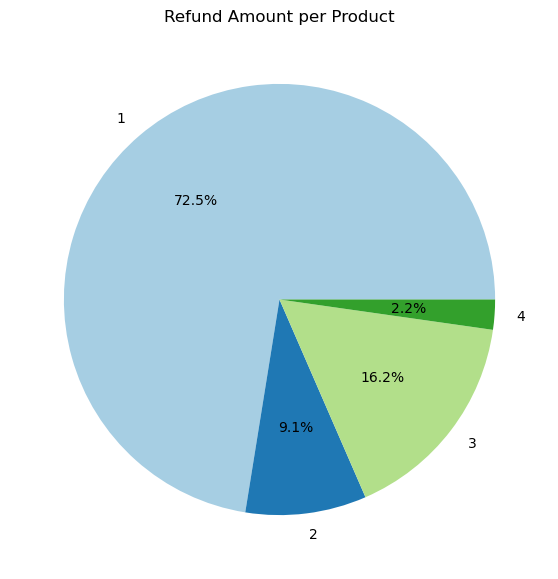

In [127]:
plt.figure(figsize=(7,7))

plt.pie(
    refund_per_product['refund_amount_usd'],
    labels=refund_per_product['product_id'].astype(str),
    autopct='%1.1f%%',
    colors=sns.color_palette("Paired", len(refund_per_product))
)

plt.title("Refund Amount per Product")
plt.show()

**Insights:**

* Product 1 accounts for the majority of refunds (72.5%).

* Product 3 has moderate refunds (16.2%).

* Product 2 contributes a smaller share (9.1%).

* Product 4 has the lowest refund percentage (2.2%).

In [128]:
prod_info=pd.merge(sales_per_product,refund_per_product,on='product_id')

In [129]:
prod_info

,product_id,sales_revenue,refund_amount_usd
0,1,1211057.74,61837.63
1,2,347702.04,7738.71
2,3,229260.15,13842.99
3,4,150489.82,1919.36


In [130]:
prod_info['net_revenue'] = prod_info['sales_revenue'] - prod_info['refund_amount_usd']

In [131]:
prod_info

,product_id,sales_revenue,refund_amount_usd,net_revenue
0,1,1211057.74,61837.63,1149220.11
1,2,347702.04,7738.71,339963.33
2,3,229260.15,13842.99,215417.16
3,4,150489.82,1919.36,148570.46


## TOTAL NET REVENUE

In [132]:
prod_info['net_revenue'].sum() #overall sales revenue

np.float64(1853171.06)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9120\4035250250.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data=prod_info, x='product_id', y='net_revenue', palette='summer')


NameError: name 'mtick' is not defined

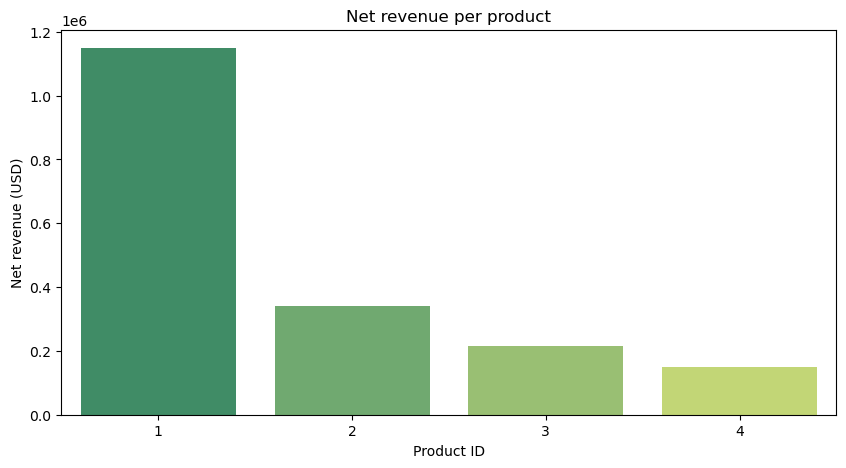

In [133]:
plt.figure(figsize=(10,5))
sns.barplot( data=prod_info, x='product_id', y='net_revenue', palette='summer')
plt.xlabel("Product ID")
plt.ylabel("Net revenue (USD)")
plt.title("Net revenue per product")
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

**Insights:**

* Product 1 generates the highest net revenue (1.15M), dominating overall earnings.

* Product 2 is a distant second (340K).

* Product 3 (220K) and Product 4 (150K) contribute significantly less.

* Revenue is heavily concentrated in Product 1.

* Product 1 is the main profit driver for the business.

## CUSTOMER LIFECYCLE ANALYSIS

In [134]:
orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


In [135]:
customer_orders = orders.groupby('user_id')['order_id'].count().reset_index()
customer_orders.columns = ['user_id', 'total_orders']
#We first count how many orders each customer placed.

In [136]:
customer_orders

,user_id,total_orders
0,13,1
1,20,1
2,59,1
3,104,1
4,147,1
...,...,...
31691,394231,1
31692,394255,1
31693,394257,1
31694,394268,1


In [137]:
customer_orders['total_orders'].unique()

array([1, 2, 3])

In [138]:
customer_orders['customer_type'] = 'New'
customer_orders.loc[customer_orders['total_orders'] > 1, 'customer_type'] = 'Repeat'
#to know the repeat customer according to the number of order placed by them 

In [139]:
customer_orders

,user_id,total_orders,customer_type
0,13,1,New
1,20,1,New
2,59,1,New
3,104,1,New
4,147,1,New
...,...,...,...
31691,394231,1,New
31692,394255,1,New
31693,394257,1,New
31694,394268,1,New


In [140]:
customer_orders['customer_type'].unique()

array(['New', 'Repeat'], dtype=object)

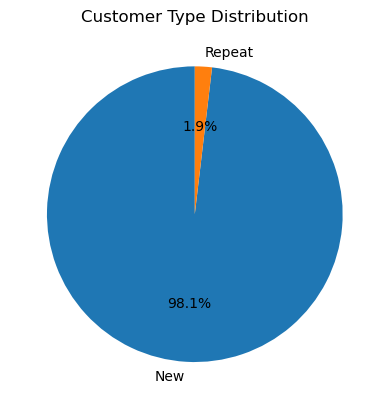

In [141]:
a= customer_orders['customer_type'].value_counts(normalize=True) * 100
plt.figure()
plt.pie(a,labels=a.index,autopct='%1.1f%%',startangle=90)
plt.title('Customer Type Distribution')
plt.show()

**Insights:**

* 98.1% of customers are new customers.

* Only 1.9% are repeat customers.

* Very low customer retention rate.

* The business is attracting new customers but needs to improve repeat purchases and customer loyalty.

## OVERALL TREND

In [142]:
orders["created_at"] = pd.to_datetime(orders["created_at"])

In [143]:
orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


In [144]:
orders['created_at'].dt.year.unique()


array([2012, 2013, 2014, 2015], dtype=int32)

In [145]:
yearly_orders = orders.groupby(orders['created_at'].dt.year).size().reset_index(name="Sales_per_year")
yearly_orders

,created_at,Sales_per_year
0,2012,2586
1,2013,7447
2,2014,16860
3,2015,5420


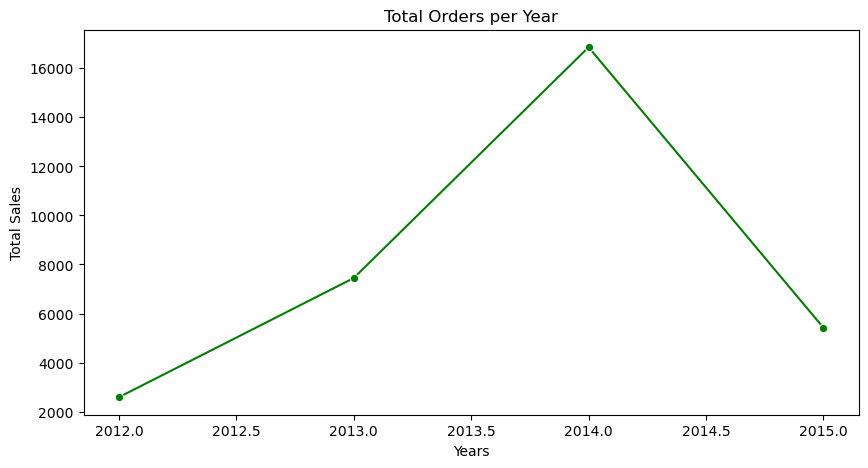

In [146]:
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_orders, x='created_at', y='Sales_per_year', marker='o',color='green')
plt.xlabel("Years")
plt.ylabel("Total Sales")
plt.title("Total Orders per Year")
plt.show()


**Insights:**

* Orders rose consistently from 2012 to 2014

* 2014 recorded the highest number of orders

* Sharp decline observed in 2015

* 2012 had the lowest order volume

* Overall trend shows growth followed by a sudden drop

In [147]:
Monthly_orders = orders.groupby(orders['created_at'].dt.month).size().reset_index(name="Orders_per_Month")
Monthly_orders

,created_at,Orders_per_Month
0,1,3470
1,2,3587
2,3,2765
3,4,1893
4,5,2047
5,6,1972
6,7,2059
7,8,2161
8,9,2340
9,10,2688


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9120\3944882187.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Monthly_orders,x='created_at',y='Orders_per_Month',palette='winter')


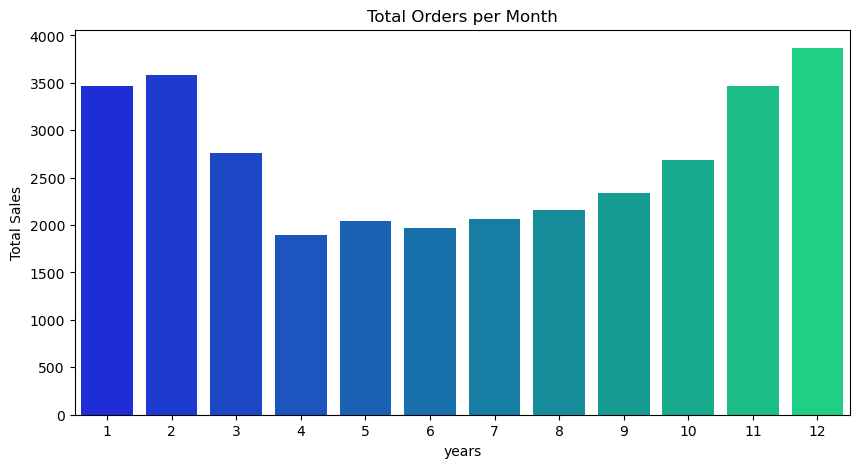

In [148]:
plt.figure(figsize=(10,5))
sns.barplot(data=Monthly_orders,x='created_at',y='Orders_per_Month',palette='winter')
plt.xlabel("years")
plt.ylabel("Total Sales")
plt.title("Total Orders per Month")
plt.show()

**Insights:**

* Highest orders recorded in Month 12

* Strong sales performance in Months 1, 2, 11, and 12

* Lowest orders observed in Month 4

* Gradual recovery in sales from Month 5 onwards

* Overall trend shows dip in early mid-year and rise toward year-end

In [149]:
weekly_orders = orders.groupby(orders['created_at'].dt.day_name()).size()
weekly_orders

created_at
Friday       5571
Monday       5662
Saturday     2309
Sunday       2538
Thursday     5414
Tuesday      5320
Wednesday    5499
dtype: int64

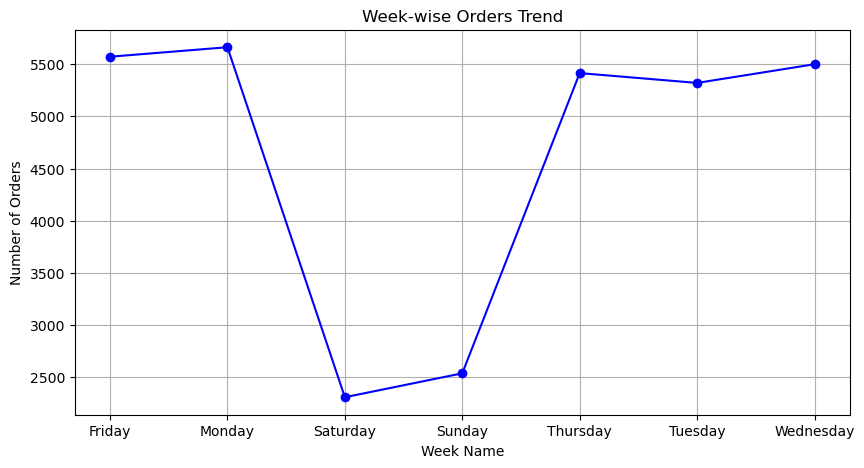

In [150]:
plt.figure(figsize=(10,5))         
plt.plot(weekly_orders, marker='o',color='blue') 
plt.title("Week-wise Orders Trend")
plt.xlabel("Week Name")
plt.ylabel("Number of Orders")
plt.grid(True)                    
plt.show()


**Insights:**

* Highest orders recorded on Monday

* Friday, Wednesday, and Thursday show strong performance

* Lowest orders observed on Saturday

* Slight improvement from Saturday to Sunday

* Weekdays perform significantly better than weekends

In [151]:
hourly_orders = orders.groupby(orders['created_at'].dt.hour).size()
hourly_orders

created_at
0      823
1      721
2      586
3      546
4      549
5      566
6      684
7      756
8     1149
9     1661
10    1948
11    2194
12    2172
13    2085
14    2153
15    2188
16    2099
17    1922
18    1593
19    1378
20    1189
21    1192
22    1131
23    1028
dtype: int64

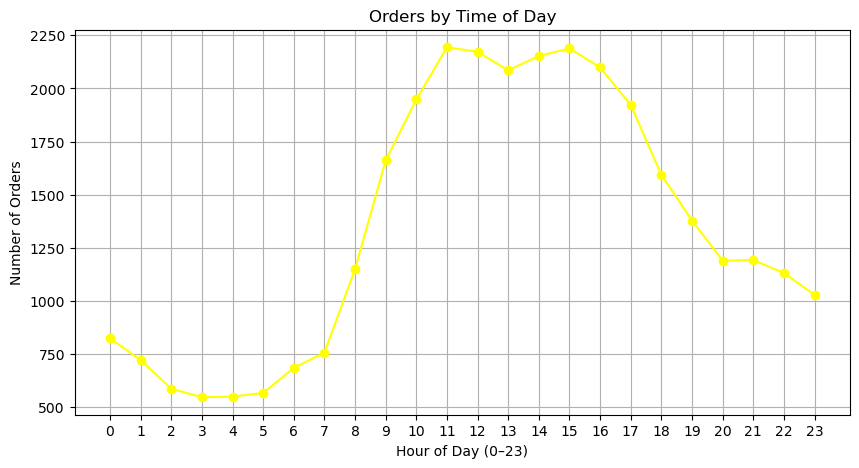

In [152]:
plt.figure(figsize=(10,5))
plt.plot(hourly_orders, marker='o',color='yellow')
plt.title("Orders by Time of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.xticks(range(24))
plt.show()

**Insights:**

* Lowest orders occur during early morning hours (2 AM – 5 AM)

* Orders start increasing steadily after 7 AM

* Peak orders recorded between 11 AM and 3 PM

* Slight decline begins after 4 PM

* Orders gradually decrease during late evening hours

* Midday period is the highest performing time of the day

## REFUND TREND

In [153]:
refunds["created_at"] = pd.to_datetime(refunds["created_at"])

In [154]:
Yearly_Refund_orders = refunds.groupby(refunds['created_at'].dt.year).size().reset_index(name="Refunds_per_Year")
Yearly_Refund_orders

,created_at,Refunds_per_Year
0,2012,169
1,2013,339
2,2014,960
3,2015,263


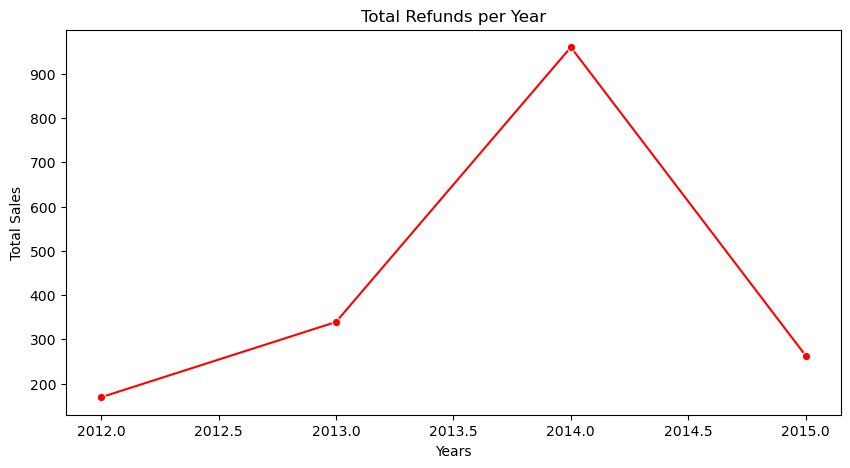

In [155]:
plt.figure(figsize=(10,5))
sns.lineplot(data=Yearly_Refund_orders, x='created_at', y='Refunds_per_Year', marker='o',color='red')
plt.xlabel("Years")
plt.ylabel("Total Sales")
plt.title("Total Refunds per Year")
plt.show()


**Insights:**

* Refunds increased steadily from 2012 to 2014

* 2014 recorded the highest number of refunds

* Significant drop in refunds in 2015

* 2012 had the lowest refund count

* Overall trend shows rise followed by sharp decline

In [156]:
Monthly_Refund_orders = refunds.groupby(refunds['created_at'].dt.to_period('M')).size().reset_index(name="Refunds_per_Month")
Monthly_Refund_orders

,created_at,Refunds_per_Month
0,2012-04,5
1,2012-05,5
2,2012-06,5
3,2012-07,13
4,2012-08,18
5,2012-09,21
6,2012-10,24
7,2012-11,40
8,2012-12,38
9,2013-01,21


In [157]:
Monthly_Refund_orders=refunds.groupby(refunds['created_at'].dt.month).size().reset_index(name="Refunds_per_Month")
Monthly_Refund_orders

,created_at,Refunds_per_Month
0,1,157
1,2,151
2,3,148
3,4,85
4,5,87
5,6,108
6,7,136
7,8,146
8,9,282
9,10,103


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9120\2597038229.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Monthly_Refund_orders,x='created_at',y='Refunds_per_Month',palette='plasma')


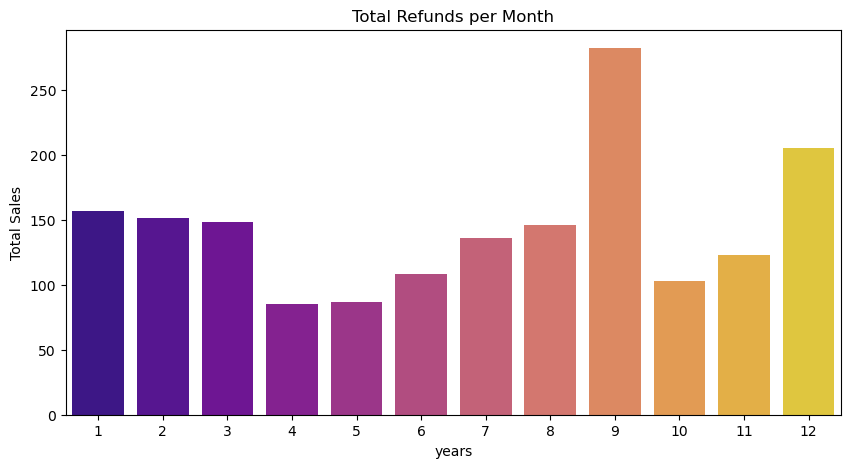

In [158]:
plt.figure(figsize=(10,5))
sns.barplot(data=Monthly_Refund_orders,x='created_at',y='Refunds_per_Month',palette='plasma')
plt.xlabel("years")
plt.ylabel("Total Sales")
plt.title("Total Refunds per Month")
plt.show()

**Insights:**

* Highest refunds recorded in Month 9

* Second highest refunds observed in Month 12

* Lowest refunds in Month 4

* Refunds decrease from Month 1 to Month 4

* Gradual increase from Month 5 to Month 9

* Slight drop after Month 9, then moderate rise toward Month 12


In [159]:
products

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


# CUSTOMER LIFECYCLE AND REPEAT BEHAVIOUR ANALYSIS

In [4]:
orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


In [5]:
order_items

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49
...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49


In [6]:
refunds

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99
...,...,...,...,...,...
1726,1727,2015-03-30 09:37:23,39950,32255,59.99
1727,1728,2015-03-30 21:33:51,39671,32049,49.99
1728,1729,2015-03-31 19:59:48,39729,32090,49.99
1729,1730,2015-04-01 03:54:48,39717,32079,59.99


## CUSTOMER SEGMENTATION (NEW & REPEAT)

In [76]:
user_orders = orders.groupby("user_id")["order_id"].count().reset_index()
user_orders.columns = ["user_id", "total_orders"]

In [77]:
user_orders["user_type"] = "New User"
user_orders.loc[user_orders["total_orders"] > 1, "user_type"] = "Repeat User"

In [78]:
user_counts =user_orders["user_type"].value_counts()
user_counts #NEW CUSTOMER COUNT

user_type
New User       31105
Repeat User      591
Name: count, dtype: int64

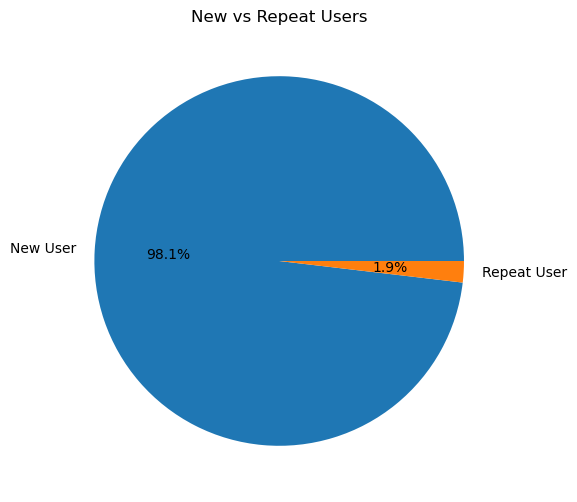

In [79]:
plt.figure(figsize=(6,6))
plt.pie(user_counts.values, labels=user_counts.index, autopct='%1.1f%%')
plt.title("New vs Repeat Users")
plt.show()

**Insights:**
* 98.1% of customers are new users, indicating the business relies heavily on first-time buyers.

* Only 1.9% of customers are repeat users, showing a very low repeat purchase rate.

* The low repeat rate suggests weak customer retention.

* There is a strong opportunity to improve loyalty programs, remarketing, and customer engagement strategies.

* Increasing repeat customers could significantly boost long-term revenue and customer lifetime value (CLV).

In [117]:
orders_ct = orders.merge(user_orders[["user_id","user_type"]], on="user_id", how="left")
orders_ct

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,order_month,user_type
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,2012-03,New User
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2012-03,New User
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,2012-03,New User
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,2012-03,New User
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,2012-03,New User
...,...,...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49,2015-03,New User
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49,2015-03,New User
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98,2015-03,New User
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49,2015-03,New User


In [81]:
total_items = orders_ct.groupby("user_type")["items_purchased"].sum().reset_index(name="total_items")

In [85]:
refunds_ct = refunds.merge(
    orders_ct[["order_id","user_type"]],
    on="order_id",
    how="left"
)

refunded_items = refunds_ct.groupby("user_type")["order_item_id"].count().reset_index(name="refunded_items")

In [86]:
summary = total_items.merge(refunded_items, on="user_type", how="left").fillna(0)

summary["refund_rate %"] = (summary["refunded_items"] / summary["total_items"]) * 100

summary = summary.set_index("user_type")
summary

,total_items,refunded_items,refund_rate %
user_type,,,
New User,38469,1662,4.320362
Repeat User,1556,69,4.434447


## ORDER FREQUENCY PER USER

In [87]:
orders_per_user = orders.groupby('user_id')['order_id'].nunique().reset_index()
orders_per_user.columns = ['user_id', 'order_count']

In [88]:
def Order_Quantity(i):
    if i == 1:
        return '1 order'
    elif i == 2:
        return '2 orders'
    else:
        return '3+ orders'

orders_per_user['order_group'] = orders_per_user['order_count'].apply(Order_Quantity)

In [89]:
order_dist = orders_per_user['order_group'].value_counts().reset_index()
order_dist.columns = ['order_group', 'num_users']

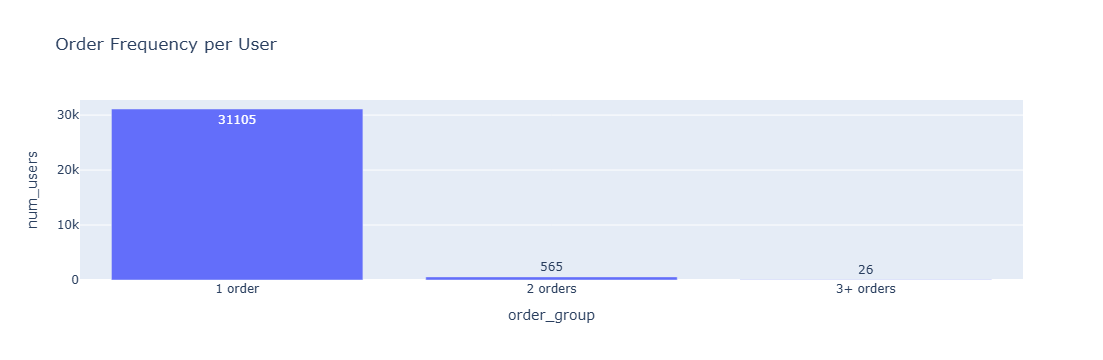

In [90]:
import plotly.express as px

px.bar(order_dist,
       x='order_group',
       y='num_users',
       text='num_users',
       title='Order Frequency per User').show()

**Insights:**

* Majority of users (31,105) placed only 1 order, indicating a very high proportion of one-time buyers.

* Only 565 users placed 2 orders, showing very low repeat purchase behavior.

* A very small group (26 users) placed 3 or more orders, representing the most loyal customers.

* The distribution shows that the business is highly dependent on new customers rather than repeat customers.

* Improving retention strategies (loyalty programs, remarketing, personalized offers) could significantly increase repeat purchases and customer lifetime value.

In [91]:
orders['created_at'] = pd.to_datetime(orders['created_at'])

In [92]:
orders['order_month'] = orders['created_at'].dt.to_period('M').astype(str)

In [93]:
first_purchase = orders.groupby('user_id')['order_month'].min().reset_index()
first_purchase.columns = ['user_id', 'cohort_month']

In [94]:
first_purchase

,user_id,cohort_month
0,13,2012-04
1,20,2012-03
2,59,2012-04
3,104,2012-03
4,147,2012-03
...,...,...
31691,394231,2015-03
31692,394255,2015-03
31693,394257,2015-03
31694,394268,2015-03


In [95]:
Orders1 = orders.merge(first_purchase, on='user_id', how='left')
Orders1

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,order_month,cohort_month
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,2012-03,2012-03
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2012-03,2012-03
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,2012-03,2012-03
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,2012-03,2012-03
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,2012-03,2012-03
...,...,...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49,2015-03,2015-03
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49,2015-03,2015-03
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98,2015-03,2015-03
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49,2015-03,2015-03


In [96]:
Orders1.dtypes

order_id                       int64
created_at            datetime64[ns]
website_session_id             int64
user_id                        int64
primary_product_id             int64
items_purchased                int64
price_usd                    float64
cogs_usd                     float64
order_month                   object
cohort_month                  object
dtype: object

In [97]:
Orders1['order_month_dt'] = pd.to_datetime(Orders1['order_month'], format='%Y-%m')
Orders1['cohort_month_dt'] = pd.to_datetime(Orders1['cohort_month'], format='%Y-%m')

In [98]:
Orders1['cohort_index'] = (
    (Orders1['order_month_dt'].dt.year - Orders1['cohort_month_dt'].dt.year) * 12 +
    (Orders1['order_month_dt'].dt.month - Orders1['cohort_month_dt'].dt.month)
)

In [99]:
cohort_data = Orders1.groupby(['cohort_month', 'cohort_index'])['user_id'].nunique().reset_index()
cohort_data 

,cohort_month,cohort_index,user_id
0,2012-03,0,60
1,2012-04,0,99
2,2012-05,0,108
3,2012-06,0,139
4,2012-06,1,1
...,...,...,...
112,2015-01,1,30
113,2015-01,2,15
114,2015-02,0,2004
115,2015-02,1,16


In [100]:
cohort_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='user_id'
)
cohort_table

cohort_index,0,1,2,3,4
cohort_month,,,,,
2012-03,60.0,NaN,NaN,NaN,NaN
2012-04,99.0,NaN,NaN,NaN,NaN
2012-05,108.0,NaN,NaN,NaN,NaN
2012-06,139.0,1.0,NaN,NaN,NaN
2012-07,168.0,NaN,NaN,NaN,NaN
2012-08,227.0,1.0,NaN,NaN,NaN
2012-09,286.0,1.0,3.0,NaN,NaN
2012-10,368.0,2.0,NaN,NaN,NaN
2012-11,612.0,2.0,1.0,NaN,1.0


## AVERAGE REPURCHASE CYCLE

In [119]:
orders['created_at'] = pd.to_datetime(orders['created_at'])

In [120]:
orders_sorted = orders.sort_values(['user_id','created_at'])

In [121]:
orders['order_number'] = orders.groupby('user_id').cumcount() + 1

In [122]:
first_orders = orders[orders['order_number'] == 1]
first_orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,order_month,order_number
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,2012-03,1
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2012-03,1
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,2012-03,1
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,2012-03,1
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,2012-03,1
...,...,...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49,2015-03,1
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49,2015-03,1
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98,2015-03,1
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49,2015-03,1


In [123]:
second_orders = orders[orders['order_number'] == 2]
second_orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,order_month,order_number
386,387,2012-06-26 21:13:49,12760,3561,1,1,49.99,19.49,2012-06,2
499,500,2012-07-19 17:43:50,15845,11071,1,1,49.99,19.49,2012-07,2
750,751,2012-08-24 13:08:47,21948,16442,1,1,49.99,19.49,2012-08,2
1063,1064,2012-09-27 10:28:01,29490,18996,1,1,49.99,19.49,2012-09,2
1174,1175,2012-10-09 20:30:23,32278,28721,1,1,49.99,19.49,2012-10,2
...,...,...,...,...,...,...,...,...,...,...
32163,32164,2015-03-17 07:38:24,470902,351605,1,2,95.98,33.98,2015-03,2
32192,32193,2015-03-17 13:34:09,471198,354670,2,1,59.99,22.49,2015-03,2
32211,32212,2015-03-17 18:25:47,471494,351985,2,1,59.99,22.49,2015-03,2
32214,32215,2015-03-17 19:04:42,471524,359445,1,2,79.98,28.98,2015-03,2


In [124]:
repurchase_data = pd.merge(first_orders, second_orders, on='user_id')
repurchase_data

,order_id_x,created_at_x,website_session_id_x,user_id,primary_product_id_x,items_purchased_x,price_usd_x,cogs_usd_x,order_month_x,order_number_x,order_id_y,created_at_y,website_session_id_y,primary_product_id_y,items_purchased_y,price_usd_y,cogs_usd_y,order_month_y,order_number_y
0,317,2012-06-11 18:56:38,10674,3561,1,1,49.99,19.49,2012-06,1,387,2012-06-26 21:13:49,12760,1,1,49.99,19.49,2012-06,2
1,355,2012-06-19 20:11:05,11835,11071,1,1,49.99,19.49,2012-06,1,500,2012-07-19 17:43:50,15845,1,1,49.99,19.49,2012-07,2
2,592,2012-08-02 10:19:15,17815,16442,1,1,49.99,19.49,2012-08,1,751,2012-08-24 13:08:47,21948,1,1,49.99,19.49,2012-08,2
3,703,2012-08-18 22:53:48,20652,18996,1,1,49.99,19.49,2012-08,1,1064,2012-09-27 10:28:01,29490,1,1,49.99,19.49,2012-09,2
4,821,2012-09-04 10:15:24,24121,22180,1,1,49.99,19.49,2012-09,1,1528,2012-11-06 15:20:39,39909,1,1,49.99,19.49,2012-11,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586,30558,2015-02-21 08:08:02,451792,377703,4,1,29.99,9.49,2015-02,1,31082,2015-03-01 18:30:39,458130,1,1,49.99,19.49,2015-03,2
587,30659,2015-02-23 14:11:56,453033,351605,1,2,79.98,28.98,2015-02,1,32164,2015-03-17 07:38:24,470902,1,2,95.98,33.98,2015-03,2
588,31349,2015-03-05 06:01:38,461351,322595,1,1,49.99,19.49,2015-03,1,31981,2015-03-13 21:06:37,468894,1,1,49.99,19.49,2015-03,2
589,31424,2015-03-06 03:54:04,462329,366677,1,1,49.99,19.49,2015-03,1,32005,2015-03-14 11:35:55,469156,1,1,49.99,19.49,2015-03,2


In [125]:
repurchase_data['created_at_x'] = pd.to_datetime(repurchase_data['created_at_x'])
repurchase_data['created_at_y'] = pd.to_datetime(repurchase_data['created_at_y'])
repurchase_data['days_between'] = (
    repurchase_data['created_at_y'] - repurchase_data['created_at_x']
).dt.days

In [126]:
average_days = repurchase_data['days_between'].mean()
print("Average Time to Second Purchase:", round(average_days,2), "days")

Average Time to Second Purchase: 34.68 days


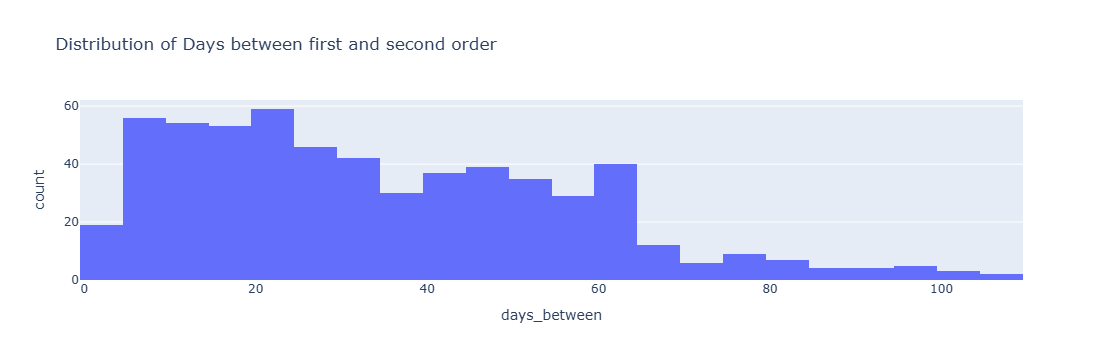

In [133]:
import plotly.express as px

fig = px.histogram(
    repurchase_data,
    x="days_between",
    nbins=40,
    title="Distribution of Days between first and second order"
)

fig.show()

**Insights:**

* Most customers place their second order within 10–40 days after the first purchase.

* The highest concentration is around 15–25 days, indicating the typical repurchase cycle.

* After 60 days, the number of repeat purchases drops significantly.

* A small number of customers take 80–100+ days to make the second purchase.

* This suggests that remarketing campaigns should target customers within the first 30 days to increase repeat purchases.

## REPEAT PURCHASE RATE PER PRODUCT

In [105]:
df = order_items.merge(
    orders[["order_id","user_id"]],
    on="order_id",
    how="left"
).merge(
    products[["product_id","product_name"]],
    on="product_id",
    how="left"
)

In [106]:
user_product = df.groupby(["product_name","user_id"]).size().reset_index(name="times_bought")

In [107]:
total_customers = user_product.groupby("product_name")["user_id"].nunique().reset_index(name="total_customers")

In [108]:
repeat_df = user_product[user_product["times_bought"] > 1]

In [109]:
repeat_customers = repeat_df.groupby("product_name")["user_id"].nunique()

In [110]:
repeat_customers = repeat_customers.reset_index()
repeat_customers.columns = ["product_name", "repeat_customers"]

In [111]:
result = total_customers.merge(repeat_customers, on="product_name", how="left").fillna(0)

result["repeat_purchase_rate_%"] = (result["repeat_customers"] / result["total_customers"]) * 100

result

,product_name,total_customers,repeat_customers,repeat_purchase_rate_%
0,The Birthday Sugar Panda,4957,27,0.544684
1,The Forever Love Bear,5776,20,0.346260
2,The Hudson River Mini bear,4982,36,0.722601
3,The Original Mr. Fuzzy,23887,326,1.364759


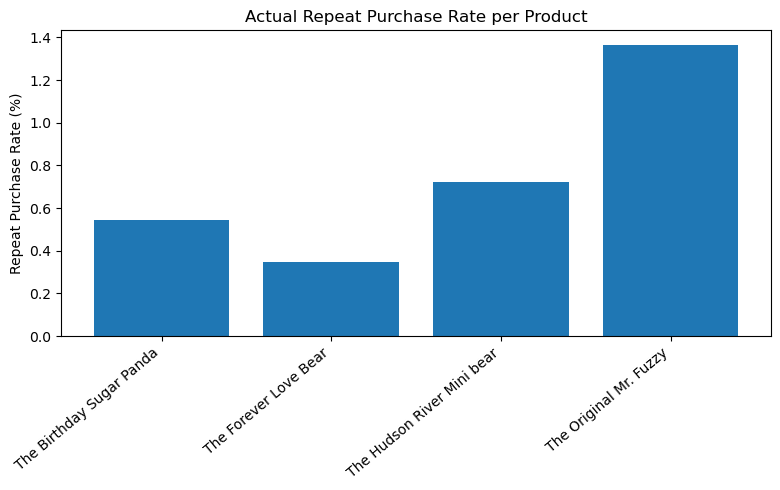

In [112]:
plt.figure(figsize=(8,5))
plt.bar(
    result['product_name'],
    result['repeat_purchase_rate_%']
)
plt.ylabel("Repeat Purchase Rate (%)")
plt.title("Actual Repeat Purchase Rate per Product")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

**Insights:**

* The Original Mr. Fuzzy has the highest repeat purchase rate (~1.36%), indicating the strongest customer loyalty.

* The Hudson River Mini Bear shows a moderate repeat purchase rate (~0.72%), suggesting decent customer retention.

* The Birthday Sugar Panda has a lower repeat purchase rate (~0.54%), meaning fewer customers repurchase it.

* The Forever Love Bear has the lowest repeat purchase rate (~0.35%), indicating the weakest repeat buying behavior.

* Products with higher repeat rates are better at building customer loyalty and long-term revenue.

In [113]:
 orders_with_type = orders.merge(
    user_orders[['user_id', 'user_type']],
    on='user_id',
    how='left'
)
orders_with_type

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,order_month,user_type
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,2012-03,New User
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2012-03,New User
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,2012-03,New User
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,2012-03,New User
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,2012-03,New User
...,...,...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49,2015-03,New User
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49,2015-03,New User
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98,2015-03,New User
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49,2015-03,New User


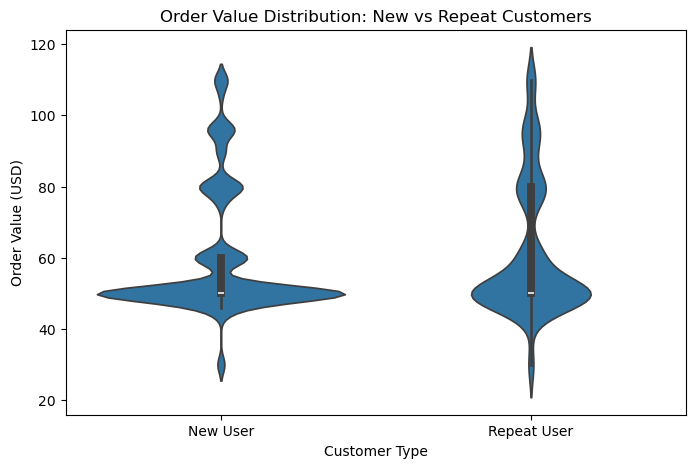

In [114]:
plt.figure(figsize=(8,5))
sns.violinplot(
    data=orders_with_type,
    x='user_type',
    y='price_usd',
    inner='box'
)
plt.title("Order Value Distribution: New vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Order Value (USD)")
plt.show()

**Insights:**

* The median order value is around $50 for both new and repeat customers.

* Repeat customers show a wider distribution, meaning they sometimes place higher-value orders.

* Most purchases for both groups are concentrated around the $45–$55 range.

* Some repeat customers place larger orders ($80–$110) compared to new users.

* This indicates repeat customers may generate higher-value purchases over time, increasing customer lifetime value.

## REPEAT CUSTOMER AOV

In [128]:
order_counts = orders.groupby('user_id')['order_id'].count()

In [129]:
repeat_customers = order_counts[order_counts > 1].index

In [130]:
repeat_orders = orders[orders['user_id'].isin(repeat_customers)]

In [131]:
repeat_aov = repeat_orders['price_usd'].sum() / repeat_orders['order_id'].count()

In [132]:
print("Repeat Customer AOV:", round(repeat_aov,2))

Repeat Customer AOV: 61.55
